In [173]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

In [174]:
# Hazır olan CIFAR 10 datasetini kullanacağız
train_data = datasets.CIFAR10(
    root= "data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)
test_data = datasets.CIFAR10(
    root="data",
    train= False,
    download=True,
    transform=ToTensor()
    )

Files already downloaded and verified


c:\Users\kaann\anaconda3\envs\deep_learning_begginning_env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified


In [175]:
train_data

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [176]:
type(train_data)

torchvision.datasets.cifar.CIFAR10

In [177]:
train_data[0]

(tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
          [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
          [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
          ...,
          [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
          [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
          [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],
 
         [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
          [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
          [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
          ...,
          [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
          [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
          [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],
 
         [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
          [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
          [0.0824, 0.0000, 0.0314,  ...,

In [178]:
type(train_data[0])

tuple

In [179]:
image , label = train_data[0]

In [180]:
image # Normalize edilmiş bir data o yüzden 0-255 arasında değil.

tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
         [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
         [0.0824, 0.0000, 0.0314,  ..., 0.1961, 0.1961, 0.

In [181]:
label # yani 6. sınıfa ait bir data     

6

In [182]:
image.shape

torch.Size([3, 32, 32])

In [183]:
len(train_data)

50000

In [184]:
len(test_data)

10000

In [185]:
class_names = train_data.classes

In [186]:
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [187]:
# Datayı nasıl görsel olarak görebiliriz.
#plt.imshow(image) # Bu şekilde yaptığımızda TypeError verir
# 3,32,32 fakat matplotlib 32,32,3 şeklinde ister
image , label = train_data[1]
image = image.permute(1,2,0)
image.shape

torch.Size([32, 32, 3])

Text(0.5, 1.0, 'truck')

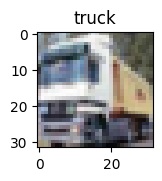

In [188]:
plt.figure(figsize=(1.5,1.5))
plt.imshow(image)
plt.title(class_names[label])

In [189]:
from torchvision import transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.4914, 0.4822, 0.4465],
                         std= [0.2470, 0.2435, 0.2616])
]) 
# Bu değerleri genelde datasetini aldığımız yerde verirler. Ya da hesaplamalarını internetten bulabilirz.
# Eğer yaygın bir dataset ise değilse de kendimiz hesaplayabiliriz.
# Normalizasyon yapmadan da eğitebiliriz fakat bu şekilde daha verimli ve hızlı olur.

In [190]:
train_data = datasets.CIFAR10(
    root= "data",
    train=True,
    download=True,
    transform=transform,
    target_transform=None
)
test_data = datasets.CIFAR10(
    root="data",
    train= False,
    download=True,
    transform=transform
    )
# download = True olduğu için tekrardan indirmedi fakat transform'da ToTensor yerine üst bloktaki transform'u kullandık

Files already downloaded and verified
Files already downloaded and verified


In [191]:
image , label = train_data[0]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9100897..2.100835].


Text(0.5, 1.0, 'truck')

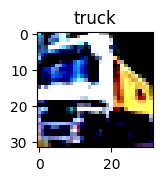

In [192]:
image , label = train_data[1]
image = image.permute(1,2,0)
plt.figure(figsize=(1.5,1.5))
plt.imshow(image)
plt.title(class_names[label])
# Biraz daha farklı bir renkte gözüküyor fakat training'imiz daha stabil olacak

In [193]:
# DataLoader kullanımı
# DataLoader elimizdeki olan datayı aslında eğitime hazırlamak için kullanırız
from torch.utils.data import DataLoader
BATCH_SIZE = 32 # Görselleri 32'şer olarak vereceğiz. # Genelde 32 ve 128 popüler olarak kullanılan sayılardır.

train_data_loader = DataLoader(train_data,batch_size=BATCH_SIZE,shuffle=True)
test_data_loader = DataLoader(test_data,batch_size=BATCH_SIZE,shuffle=False)
# Test datasında shuffle etmemiz önemli değil.
# Fakat trian kısmında weights'leri güncelleyeceğimiz için shuffle'ın önemi var.

In [194]:
len(train_data_loader), len(test_data_loader)
# 1563*32 = 50016 burada son batch'te 16 data eksiğimiz var önemi yok
# 313*32=10016 burada da aynı şekilde.

(1563, 313)

In [195]:
train_data_loader.dataset[0][0].shape
# image kısmının shape'i hala aynı. Sadece shuffle ve Batch_Size kısmını yaptık.

torch.Size([3, 32, 32])

In [196]:
# flatten layer
flatten_model = nn.Flatten()

first_data = train_data_loader.dataset[0][0]
flattened_data = flatten_model(first_data)

print(first_data.shape)
print(flattened_data.shape)
# linear layer'a 3,3,32 şeklinde versek sıkıntıydı onun yerine flatten_layer kullanarak 3,1024 haline getirdik

torch.Size([3, 32, 32])
torch.Size([3, 1024])


In [197]:
class CIFAR10Classifier(nn.Module):

    def __init__(self,input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        #self.layer_stack = nn.Sequential(
            #nn.Flatten(),
            #nn.Linear(in_features=3072,out_features=32), # in_fetaures 1024*3
            #nn.Linear(in_features=32,out_features=10) # out_features = 10 cünkü 10 tane sınıfmız var
        #)
        # Tabi bu yaptığımız en manuel versiyonu bunu dinamik hale getirmek için şöyle yaparız
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape,out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )
    
    def forward(self,x):
        return self.layer_stack(x)

In [198]:
first_data.shape

torch.Size([3, 32, 32])

In [199]:
3 * 32 * 32 # 3072 feature'imiz var.

3072

In [200]:
len(class_names) # kaç sınıfımız olduğu

10

In [201]:
torch.manual_seed(42)

model_0 = CIFAR10Classifier(
    input_shape=3072,
    hidden_units=32,
    output_shape=len(class_names)
    )

In [202]:
#model_0 = torch.compile(model_0)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),lr =0.001)

In [203]:
def calculate_accuracy(y_true, y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [204]:
torch.manual_seed(42)

epochs = 10

for epoch in range(epochs):

    train_loss = 0
    
    for batch, (X,y) in enumerate(train_data_loader):
        # önce batchleri biticez sonra diğer epoch'a gececeğiz
        model_0.train()

        y_pred = model_0(X)

        loss = loss_fn(y_pred,y)
        train_loss += loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 500 == 0:
            print(f"Batch number: {batch}")
    
    train_loss /= len(train_data_loader)

    test_loss = 0
    test_acc = 0
    model_0.eval()
    with torch.inference_mode():
        for X,y in test_data_loader:
            test_pred = model_0(X)
            test_loss += loss_fn(test_pred, y)
            test_acc += calculate_accuracy(y_true = y, y_pred= test_pred.argmax(dim=1))
        test_loss /= len(test_data_loader)
        test_acc /= len(test_data_loader)
    print(f"Train loss: {train_loss}, Test loss: {test_loss}, Test Accuracy: {test_acc}")
# Aslında bu modeli biz Linear mimarinin işe yaramayacağını göstermek için kurdk
# Sonuçlardan göründüğü üzere çokta anlamlı sonuçlar vermiyor.


Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 1.8509423732757568, Test loss: 1.7688896656036377, Test Accuracy: 38.26876996805112
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 1.759240984916687, Test loss: 1.755340814590454, Test Accuracy: 38.927715654952074
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 1.7459595203399658, Test loss: 1.7602170705795288, Test Accuracy: 38.02915335463259
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 1.732830286026001, Test loss: 1.7578070163726807, Test Accuracy: 38.977635782747605
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 1.7242060899734497, Test loss: 1.766834020614624, Test Accuracy: 38.468450479233226
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 1.7180931568145752, Test loss: 1.756719708442688, Test Accuracy: 39.007587859

In [205]:
# Birde modellerin karşılaştırılması için bir fonksiyon ekleyelim
def evaluate_model_performance(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader,
                               loss_fn : torch.nn.Module, accuracy_function):
    loss = 0
    acc = 0
    model.eval()
    with torch.inference_mode():
        for X,y in data_loader:
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_function(y_true = y, y_pred = y_pred.argmax(dim=1))
        loss /= len(data_loader)
        acc /= len(data_loader)
    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_accuracy:": acc}

In [206]:
model_0_results = evaluate_model_performance(model=model_0,data_loader=test_data_loader,
                                             loss_fn = loss_fn, accuracy_function=calculate_accuracy)
model_0_results

{'model_name': 'CIFAR10Classifier',
 'model_loss': 1.766856074333191,
 'model_accuracy:': 38.7879392971246}

In [207]:
# Non linear bir modelle deneyelim.
class CIFAR10ClassifierNonLinear(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,out_features=output_shape)
        )
    def forward(self, x):
        return self.layer_stack(x)

In [208]:
torch.manual_seed(42)
model_1 = CIFAR10ClassifierNonLinear(input_shape= 3072, hidden_units=32, output_shape=len(class_names))

In [209]:
optimizer = torch.optim.Adam(params=model_1.parameters(),lr=0.001)
# loss_fn aynı olacağı için tanımlamadım tekrardan

In [210]:
torch.manual_seed(42)

epochs = 10

for epoch in range(epochs):

    train_loss = 0

    for batch, (X,y) in enumerate(train_data_loader):
        model_1.train()

        y_pred = model_1(X)

        loss = loss_fn(y_pred,y)
        train_loss += loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 500 == 0:
            print(f"Batch number: {batch}")
        
    train_loss /= len(train_data_loader)

    test_loss = 0
    test_acc = 0

    model_1.eval()
    with torch.inference_mode():
        for X, y in test_data_loader:
            test_pred = model_1(X)
            test_loss += loss_fn(test_pred,y)
            test_acc += calculate_accuracy(y,test_pred.argmax(dim=1))

        test_loss /= len(test_data_loader)
        test_acc /= len(test_data_loader)

    print(f"Train loss: {train_loss}, Test loss: {test_loss}, Test accuracy: {test_acc}")


Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 1.7238211631774902, Test loss: 1.5794956684112549, Test accuracy: 44.179313099041536
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 1.553303599357605, Test loss: 1.5388309955596924, Test accuracy: 45.23761980830671
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 1.4976284503936768, Test loss: 1.5456594228744507, Test accuracy: 45.32747603833866
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 1.459911584854126, Test loss: 1.5103951692581177, Test accuracy: 46.65535143769968
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 1.4283552169799805, Test loss: 1.5080033540725708, Test accuracy: 47.09464856230032
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 1.4047554731369019, Test loss: 1.5008553266525269, Test accuracy: 47.14456869

In [211]:
model_1_results = evaluate_model_performance(model=model_1,data_loader=test_data_loader,loss_fn=
                                             loss_fn,accuracy_function=calculate_accuracy)

In [212]:
model_1_results

{'model_name': 'CIFAR10ClassifierNonLinear',
 'model_loss': 1.510938048362732,
 'model_accuracy:': 47.04472843450479}

In [213]:
model_0_results
# Bakınca loss'ta biraz düşüş accuracy'de artış var fakat hani yine 27 accuracy'de kötü.

{'model_name': 'CIFAR10Classifier',
 'model_loss': 1.766856074333191,
 'model_accuracy:': 38.7879392971246}

In [214]:
# Şimdi ANN değilde CNN Kullanarak yapalım. Asıl bu kullanılır zaten görüntü işlemede
# Burada VGG mimarisin kopyalayaacğız
# https://poloclub.github.io/cnn-explainer/ bu siteden mimariyi kurarken yardım alabiliriz
# Örneğin input size, padding, kernel size, stride ayarlarken simülasyonunu görebiliyoruz.
# veya convolution ve relu gibi katmanlarıda görebiliyoruz.
class CIFAR10ClassifierCNN(nn.Module):

    def __init__(self,input_shape: int,hidden_units: int,output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3, # -> 3 demek (3x3) matrix demek
                      stride=1,
                      padding=1), # 2 boyutlu olduğu için Conv2d'yi seçtik 1d ve 3d versiyonuda var
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # Bunlar VGG mimarisine göre
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        # CNN'ler CNN + ANN olarak çalışır en sonda bir dense layer olmalı
        # Şu anda da ANN kısmını yazıyoruz
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 8 * 8,
                      out_features=output_shape)
        )

    def forward(self, x):
        return self.classifier(self.block_2(self.block_1(x)))

In [215]:
#torch.manual_seed(42)

model_2 = CIFAR10ClassifierCNN(input_shape = 3,
                                hidden_units = 32,
                                output_shape = len(class_names))

In [216]:
# loss_fn yine aynı olacak 
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_2.parameters(),lr=0.001)

In [217]:
#torch.manual_seed(42)

epochs = 10

for epoch in range(epochs):

    train_loss = 0

    for batch, (X,y) in enumerate(train_data_loader):
        model_2.train()

        y_pred = model_2(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 500 ==0 :
            print(f"Batch Number: {batch}")
    
    train_loss /= len(train_data_loader)

    test_loss = 0
    test_acc = 0
    
    model_2.eval()
    with torch.inference_mode():
        for X,y in test_data_loader:
            test_pred = model_2(X)
            test_loss += loss_fn(test_pred, y)
            test_acc += calculate_accuracy(y_true=y, y_pred = test_pred.argmax(dim=1))

        test_loss /= len(test_data_loader)
        test_acc /= len(test_data_loader)

    print(f"Train loss: {train_loss}, Test_loss: {test_loss}, Test accuracy: {test_acc}")

Batch Number: 0
Batch Number: 500
Batch Number: 1000
Batch Number: 1500
Train loss: 1.3360438346862793, Test_loss: 1.1218122243881226, Test accuracy: 61.14217252396166
Batch Number: 0
Batch Number: 500
Batch Number: 1000
Batch Number: 1500
Train loss: 0.9365013241767883, Test_loss: 0.9366061091423035, Test accuracy: 67.66174121405751
Batch Number: 0
Batch Number: 500
Batch Number: 1000
Batch Number: 1500
Train loss: 0.8058379292488098, Test_loss: 0.8739719390869141, Test accuracy: 70.3873801916933
Batch Number: 0
Batch Number: 500
Batch Number: 1000
Batch Number: 1500
Train loss: 0.7254735231399536, Test_loss: 0.7857338190078735, Test accuracy: 72.67372204472844
Batch Number: 0
Batch Number: 500
Batch Number: 1000
Batch Number: 1500
Train loss: 0.6704491972923279, Test_loss: 0.8177390098571777, Test accuracy: 72.2344249201278
Batch Number: 0
Batch Number: 500
Batch Number: 1000
Batch Number: 1500
Train loss: 0.6249209046363831, Test_loss: 0.800345242023468, Test accuracy: 73.0131789137

In [219]:
model_2_results = evaluate_model_performance(model=model_2, data_loader=test_data_loader,
    loss_fn=loss_fn, accuracy_function=calculate_accuracy)

In [220]:
model_2_results

{'model_name': 'CIFAR10ClassifierCNN',
 'model_loss': 0.8575106859207153,
 'model_accuracy:': 72.30431309904154}

In [221]:
def make_predictions(model: torch.nn.Module, data: list):
    """
    data: [img_tensor, img_tensor, ...]  # her biri [C, H, W]
    return: [N, num_classes] olasılık tensörü
    """
    pred_probs = []
    model.eval()

    with torch.inference_mode():
        for sample in data:
            # [C, H, W] -> [1, C, H, W]
            sample = sample.unsqueeze(0)

            # Logits al
            pred_logit = model(sample)    # shape: [1, num_classes]

            # Softmax ile olasılığa çevir
            prob = torch.softmax(pred_logit, dim=1)  # [1, num_classes]

            # Batch boyutunu sıkıştır
            pred_probs.append(prob.squeeze(0))       # [num_classes]

    # Hepsini birleştir → [N, num_classes]
    return torch.stack(pred_probs)

In [222]:
import random
def show_random_predictions(model, dataset, class_names, n=9):
    model.eval()
    
    plt.figure(figsize=(4, 4))

    # random 9 index seç
    indices = random.sample(range(len(dataset)), n)

    with torch.inference_mode():
        for i, idx in enumerate(indices):
            img, true_label = dataset[idx]

            # modele uygun hale getir
            img_input = img.unsqueeze(0)  
            logits = model(img_input)
            pred_label = logits.argmax(dim=1).item()

            # görseli çizmek için permute
            img_show = img.permute(1, 2, 0)

            # doğru mu yanlış mı?
            correct = (pred_label == true_label)
            color = "green" if correct else "red"

            # subplot
            plt.subplot(3, 3, i + 1)
            plt.imshow(img_show)
            plt.axis("off")

            plt.title(
                f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}",
                color=color,
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1003731..2.1264887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8307058..2.0620687].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5937674..2.1264887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9641825..2.1264887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.735445..1.3764071].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7513218..2.0591094].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6903974

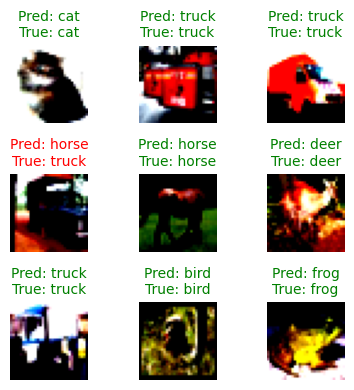

In [224]:
show_random_predictions(model_2, test_data, class_names)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.195634..1.8204937].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9577202..1.9797254].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5937674..2.055863].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0258815].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7548175..2.0137537].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.6433387].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9158674.

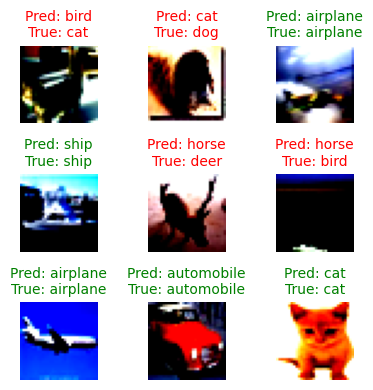

In [229]:
show_random_predictions(model_1, test_data, class_names)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1264887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6401843..2.115826].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7065024..2.0108907].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8783362..2.1264887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8031324..1.9493337].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4971374..2.115826].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9158674.

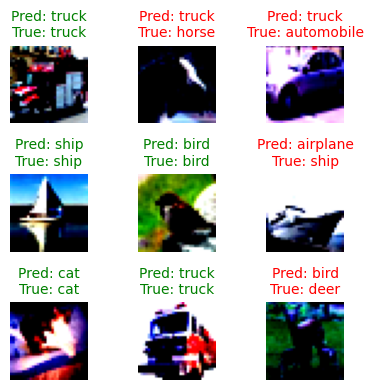

In [228]:
show_random_predictions(model_0, test_data, class_names)